In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, ttest_rel, t, norm, stats, nbinom
from scipy import stats

In [17]:
df_raw = pd.read_csv('diabetic_data.csv')
df_raw = df_raw[['diag_1']]
df_raw

,diag_1
0,250.83
1,276
2,648
3,8
4,197
...,...
101761,250.13
101762,560
101763,38
101764,996


In [18]:
def map_icd9(code):

    if pd.isna(code):
        return 'Missing'

    code = str(code).strip()

    if code.startswith('V'):
        return 'Supplementary_Factors'

    if code.startswith('E'):
        return 'External_Causes'

    try:
        num = float(code)
    except ValueError:
        return 'Unknown'

    if 1 <= num <= 139:
        return 'Infectious_Parasitic'

    elif 140 <= num <= 239:
        return 'Neoplasms'

    elif 240 <= num <= 279:
        return 'Endocrine_Metabolic_Immunity'

    elif 280 <= num <= 289:
        return 'Blood_Diseases'

    elif 290 <= num <= 319:
        return 'Mental_Disorders'

    elif 320 <= num <= 389:
        return 'Nervous_Sense_Organs'

    elif 390 <= num <= 459:
        return 'Circulatory'

    elif 460 <= num <= 519:
        return 'Respiratory'

    elif 520 <= num <= 579:
        return 'Digestive'

    elif 580 <= num <= 629:
        return 'Genitourinary'

    elif 630 <= num <= 679:
        return 'Pregnancy_Childbirth'

    elif 680 <= num <= 709:
        return 'Skin_Subcutaneous'

    elif 710 <= num <= 739:
        return 'Musculoskeletal'

    elif 740 <= num <= 759:
        return 'Congenital_Anomalies'

    elif 760 <= num <= 779:
        return 'Perinatal'

    elif 780 <= num <= 799:
        return 'Symptoms_IllDefined'

    elif 800 <= num <= 999:
        return 'Injury_Poisoning'

    else:
        return 'Unknown'


df_raw['diag_1'] = df_raw['diag_1'].apply(map_icd9)
df_raw

,diag_1
0,Endocrine_Metabolic_Immunity
1,Endocrine_Metabolic_Immunity
2,Pregnancy_Childbirth
3,Infectious_Parasitic
4,Neoplasms
...,...
101761,Endocrine_Metabolic_Immunity
101762,Digestive
101763,Infectious_Parasitic
101764,Injury_Poisoning


In [19]:
df = pd.read_csv('diabetic_encoded.csv')
df

,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diag_Musculoskeletal,diag_Mental_Disorders,diag_Skin_Subcutaneous,diag_Circulatory,diag_External_Causes,diag_Genitourinary,diag_Digestive,diag_Symptoms_IllDefined,diag_Supplementary_Factors,diag_Blood_Diseases
0,8222157,0.0,0,1,41,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,55629189,0.0,1,3,59,0,18,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,86047875,0.0,2,2,11,5,13,2,0,1,...,0,0,0,0,0,0,0,0,1,0
3,82442376,1.0,3,2,44,1,16,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,42519267,1.0,4,1,51,0,8,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,100162476,1.0,7,3,51,0,16,0,0,0,...,0,1,0,1,0,0,0,0,0,0
101762,74694222,0.0,8,5,33,3,18,0,0,1,...,0,0,0,0,0,0,1,1,0,0
101763,41088789,1.0,7,1,53,0,9,1,0,0,...,0,1,0,0,0,1,0,0,0,0
101764,31693671,0.0,8,10,45,2,21,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [20]:
df = df.join(df_raw)
df

,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diag_Mental_Disorders,diag_Skin_Subcutaneous,diag_Circulatory,diag_External_Causes,diag_Genitourinary,diag_Digestive,diag_Symptoms_IllDefined,diag_Supplementary_Factors,diag_Blood_Diseases,diag_1
0,8222157,0.0,0,1,41,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,Endocrine_Metabolic_Immunity
1,55629189,0.0,1,3,59,0,18,0,0,0,...,0,0,0,0,0,0,0,0,0,Endocrine_Metabolic_Immunity
2,86047875,0.0,2,2,11,5,13,2,0,1,...,0,0,0,0,0,0,0,1,0,Pregnancy_Childbirth
3,82442376,1.0,3,2,44,1,16,0,0,0,...,0,0,1,0,0,0,0,0,0,Infectious_Parasitic
4,42519267,1.0,4,1,51,0,8,0,0,0,...,0,0,0,0,0,0,0,0,0,Neoplasms
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,100162476,1.0,7,3,51,0,16,0,0,0,...,1,0,1,0,0,0,0,0,0,Endocrine_Metabolic_Immunity
101762,74694222,0.0,8,5,33,3,18,0,0,1,...,0,0,0,0,0,1,1,0,0,Digestive
101763,41088789,1.0,7,1,53,0,9,1,0,0,...,1,0,0,0,1,0,0,0,0,Infectious_Parasitic
101764,31693671,0.0,8,10,45,2,21,0,0,1,...,0,0,0,0,0,0,0,0,1,Injury_Poisoning


я посмотрела на pairplot из EDA (тут он отказался рисоваться, поэтому нарисовала там). я сделала цвета по readmittion. 

можно заметить, что в колонке num_inpatient все значения левее - без повторной госпитализации, а значения правее - с ней (причем и >30 дней и меньше). отсюда вытекает первая гипотеза - мы хотим проверить, связано ли количество прошлых госпитализаций с фактом повторной госпитализации сейчас.

итак:

нулевая гипотеза H<sub>0</sub>: распределение number_inpatient в выборках людей с и без повторной госпитализации одинаково.

альтернативная гипотеза H<sub>1</sub>: распределение number_inpatient в выборке людей с повторной госпитализацией юольше, чем в группе без.

посмотрим на сами распределения

In [33]:
df_n = df[df['readmitted'] == 0][['number_inpatient', 'readmitted']]
df_n

,number_inpatient,readmitted
0,0,0
2,1,0
3,0,0
4,0,0
6,0,0
...,...,...
101759,0,0
101762,1,0
101763,0,0
101764,1,0


In [34]:
df_y = df[df['readmitted'] > 0][['number_inpatient', 'readmitted']]
df_y

,number_inpatient,readmitted
1,0,1
5,0,1
7,0,1
10,0,1
11,0,2
...,...,...
101754,0,1
101755,0,1
101756,1,1
101760,2,1


в группе без повторной госпитализации 54864 объекта, в группе с - 46902. для такого большого числа объектов можно сказать, что это примерно равное распределение групп и дисбаланса особо нет. 

In [42]:
df['re_bin'] = (df['readmitted'] > 0).astype(int)
df

,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diag_Skin_Subcutaneous,diag_Circulatory,diag_External_Causes,diag_Genitourinary,diag_Digestive,diag_Symptoms_IllDefined,diag_Supplementary_Factors,diag_Blood_Diseases,diag_1,re_bin
0,8222157,0.0,0,1,41,0,1,0,0,0,...,0,0,0,0,0,0,0,0,Endocrine_Metabolic_Immunity,0
1,55629189,0.0,1,3,59,0,18,0,0,0,...,0,0,0,0,0,0,0,0,Endocrine_Metabolic_Immunity,1
2,86047875,0.0,2,2,11,5,13,2,0,1,...,0,0,0,0,0,0,1,0,Pregnancy_Childbirth,0
3,82442376,1.0,3,2,44,1,16,0,0,0,...,0,1,0,0,0,0,0,0,Infectious_Parasitic,0
4,42519267,1.0,4,1,51,0,8,0,0,0,...,0,0,0,0,0,0,0,0,Neoplasms,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,100162476,1.0,7,3,51,0,16,0,0,0,...,0,1,0,0,0,0,0,0,Endocrine_Metabolic_Immunity,1
101762,74694222,0.0,8,5,33,3,18,0,0,1,...,0,0,0,0,1,1,0,0,Digestive,0
101763,41088789,1.0,7,1,53,0,9,1,0,0,...,0,0,0,1,0,0,0,0,Infectious_Parasitic,0
101764,31693671,0.0,8,10,45,2,21,0,0,1,...,0,0,0,0,0,0,0,1,Injury_Poisoning,0


<Axes: xlabel='number_inpatient', ylabel='Count'>

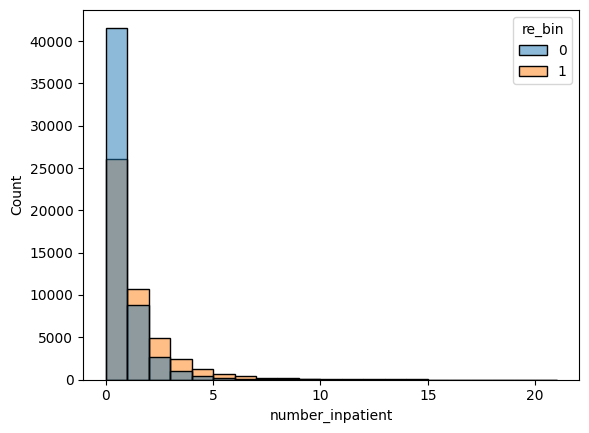

In [43]:
sns.histplot(df, x='number_inpatient', hue='re_bin', binwidth=1)

мы хотим сравнивать распределения двух групп, поэтому нам нужен подходящий тест для этого. одним из вариантов является т-тест. для него требуется нормальность распределения данных. по гистограмме выше видно, что данные точно не распределены нормально, но можно так же проверить это с помощью теста Шапиро. однако тест Шапиро довольно плохо работает с большими объемами данных, тк чувствителен даже к небольшим отклонениям, так что его мы проведем на подвыборках

тут у нас будет нулевая гипотеза H<sub>0</sub>: распеределение данных нормальное

альтернативная гипотеза H<sub>1</sub>: данные имеют распределение, отличное от нормального

уровень значимости 0.05

In [44]:
from scipy.stats import shapiro

In [45]:
for i in range(1, 100, 10):
    y = df_y['number_inpatient'].sample(500, random_state=i)
    n = df_n['number_inpatient'].sample(500, random_state=i)
    print(f'тест на y (с readmittion): {shapiro(y)}')
    print(f'тест на n (с readmittion): {shapiro(n)}')

тест на y (с readmittion): ShapiroResult(statistic=np.float64(0.6747480636720824), pvalue=np.float64(7.664955545765886e-30))
тест на n (с readmittion): ShapiroResult(statistic=np.float64(0.5039584049790057), pvalue=np.float64(4.478608261408774e-35))
тест на y (с readmittion): ShapiroResult(statistic=np.float64(0.6300601590504487), pvalue=np.float64(2.163888522148203e-31))
тест на n (с readmittion): ShapiroResult(statistic=np.float64(0.537829043061048), pvalue=np.float64(3.6230180361318415e-34))
тест на y (с readmittion): ShapiroResult(statistic=np.float64(0.6294399747068073), pvalue=np.float64(2.064453567979597e-31))
тест на n (с readmittion): ShapiroResult(statistic=np.float64(0.42524839337681897), pvalue=np.float64(5.2533223182757895e-37))
тест на y (с readmittion): ShapiroResult(statistic=np.float64(0.6758260255195601), pvalue=np.float64(8.392932113510432e-30))
тест на n (с readmittion): ShapiroResult(statistic=np.float64(0.5142086644295305), pvalue=np.float64(8.327108804214565e-35)

у нас везде получились очень маленькие значения p-value (<0.05), значит мы отклоняем нулевую гипотезу и принимаем альтернативную о том, что данные не распределены нормально (на 10 подвыборках для каждой группы и на гистограмме, так что решение проверено).

итак, мы имеем данные, которые распределены не нормально. т-тест на таких данных работает некорректно, так что будем использовать его аналог - тест U-критерий Манна-Уитни. 

только U-критерий не сравнивает сразу медианы, он определяет сдвиг распределений относительно друг друга. так что сформулирую гипотезы таким образом. (это из моего дз если что)

нулевая гипотеза H<sub>0</sub>: распеределения не сдвинуты относительно друг друга

альтернативная гипотеза H<sub>1</sub>: распределение df_y['number_inpatient'] больше df_n['number_inpatient']

уровень значимости возьмем 0.01, тк выборка очень большая

In [46]:
from scipy.stats import mannwhitneyu

In [50]:
mannwhitneyu(df_y['number_inpatient'], df_n['number_inpatient'], alternative='greater')

MannwhitneyuResult(statistic=np.float64(1572533986.0), pvalue=np.float64(0.0))

значение p-value получилось очень маленькое: p-value < 0.01, значит отвергаем нулевую гипотезу и принимаем альтернативную о том, что распределения сдвинуты относительно друг друга. и, в соответствии с нашими изначальными формулировками - распределение number_inpatient в выборке людей с повторной госпитализацией юольше, чем в группе без.

итак, мы посмотрели на гипотезы с бинарным значением readmittion. но у нас оно тернарное, а это позволяет сделать ещё один интересный тест - тест Краскала-Уоллиса.